# 公民館データ分析（情報追加ver.）

####  公民館データに属性情報を一つ追加した場合の分析可能の模索

#### [1]読み込み
#### [2]前処理
- SSMSからcsv作成時による不要行の削除
#### [3]属性情報追加
- 各公民館の「貸出可能部屋数」の情報を追加
#### [4]可視化
- 公民館ごとの一番近い公営住宅との距離比較
- 距離順に並び変え
#### [4]集計
- 男女別、年齢3区分別の人口と比率を集計
- グラフは一番近い公営住宅との距離順に表示

## 【読み込み】

### 1.ライブラリ読み込み

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
# グラフのスタイル
plt.style.use('ggplot')
# 日本語用フォント設定
plt.rcParams["font.family"] = "Meiryo"

### 2.データ読み込み

In [2]:
# 公共施設データ
df = pd.read_csv("../data/analysis_public_facilities.csv")

### 3.データ確認

In [3]:
df.head(3)

,facility_No,facility_name,available_days,facility_area_name,housing_No,housing_name,housing_area_name,distance_m_to_nearest_housing,area,total_population,...,female_45_49,female_50_54,female_55_59,female_60_64,female_65_69,female_70_74,female_75_79,female_80_84,female_85_89,female_90_plus
0,78,盛岡市上田公民館,火水木金土日,上田,10.0,前九年アパート,前九年,1525.622140,上田,4261.0,...,135.0,167.0,141.0,154.0,123.0,106.0,130.0,89.0,83.0,90.0
1,77,盛岡市中央公民館,火水木金土日,愛宕町,11.0,つつじが丘住宅,つつじが丘,2036.267547,愛宕町,957.0,...,43.0,56.0,44.0,38.0,21.0,35.0,36.0,24.0,16.0,19.0
2,90,盛岡市薮川地区公民館,火水木金土日,薮川字外山,11.0,つつじが丘住宅,つつじが丘,14161.198793,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.tail(3)

,facility_No,facility_name,available_days,facility_area_name,housing_No,housing_name,housing_area_name,distance_m_to_nearest_housing,area,total_population,...,female_45_49,female_50_54,female_55_59,female_60_64,female_65_69,female_70_74,female_75_79,female_80_84,female_85_89,female_90_plus
13,81,盛岡市西部公民館,火水木金土日,南青山町,7.0,青山一丁目アパ−ト,青山,254.341376,南青山町,1596.0,...,73.0,68.0,65.0,49.0,53.0,67.0,57.0,48.0,56.0,50.0
14,(14 行に影響しました),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15,完了時刻: 2026-05-27T11:28:02.0978319+09:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# サイズ確認
print(df.shape)

(16, 50)


## 【前処理】

### 1.不要行削除

In [6]:
#### SSMSで出力結果が区切られておらず、1列になっていた
#### 　→　「コンマ区切り」に設定変更したことで解決
#### 以下2つの操作が不要に

In [7]:
##【パターン１】
#　0行目を削除して、インデックス振り直し
# df = df.drop(0).reset_index(drop=True)

In [8]:
##【パターン２】
# 1行目以降をスライス、インデックス振り直し
#df = df.iloc[1:].reset_index(drop=True)

#### 【後ろ2行】SQL Serverの実行結果であり、不要

In [9]:
# 確認してみる
df.tail(3)

,facility_No,facility_name,available_days,facility_area_name,housing_No,housing_name,housing_area_name,distance_m_to_nearest_housing,area,total_population,...,female_45_49,female_50_54,female_55_59,female_60_64,female_65_69,female_70_74,female_75_79,female_80_84,female_85_89,female_90_plus
13,81,盛岡市西部公民館,火水木金土日,南青山町,7.0,青山一丁目アパ−ト,青山,254.341376,南青山町,1596.0,...,73.0,68.0,65.0,49.0,53.0,67.0,57.0,48.0,56.0,50.0
14,(14 行に影響しました),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15,完了時刻: 2026-05-27T11:28:02.0978319+09:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
# 後ろ2行をそれぞれlistで表示
print(df.iloc[-1].tolist())
print(df.iloc[-2].tolist())

['完了時刻: 2026-05-27T11:28:02.0978319+09:00', nan, nan, nan, np.float64(nan), nan, nan, np.float64(nan), nan, np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan)]
['(14 行に影響しました)', nan, nan, nan, np.float64(nan), nan, nan, np.float64(nan), nan, np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(

In [11]:
# 後ろ2行前をスライス、インデックス振り直し
df = df.iloc[:-2].reset_index(drop=True)

In [12]:
# 確認
df.tail(2)

,facility_No,facility_name,available_days,facility_area_name,housing_No,housing_name,housing_area_name,distance_m_to_nearest_housing,area,total_population,...,female_45_49,female_50_54,female_55_59,female_60_64,female_65_69,female_70_74,female_75_79,female_80_84,female_85_89,female_90_plus
12,83,盛岡市松園地区公民館,月火水木金土日,東松園,2.0,岩脇緑が丘住宅,岩脇町,2069.572058,東松園,2632.0,...,81.0,97.0,82.0,84.0,101.0,131.0,207.0,136.0,70.0,42.0
13,81,盛岡市西部公民館,火水木金土日,南青山町,7.0,青山一丁目アパ−ト,青山,254.341376,南青山町,1596.0,...,73.0,68.0,65.0,49.0,53.0,67.0,57.0,48.0,56.0,50.0


In [13]:
# サイズ確認
print(df.shape)

(14, 50)


## 【属性情報追加】

### rentable_room_count - 公民館の「貸出可能な部屋の数」

In [14]:
df['facility_name'].tolist()

['盛岡市上田公民館',
 '盛岡市中央公民館',
 '盛岡市薮川地区公民館',
 '盛岡市河南公民館',
 '盛岡市飯岡地区公民館',
 '盛岡市都南公民館',
 '盛岡市見前地区公民館',
 '盛岡市見前南地区公民館',
 '盛岡市乙部地区公民館',
 '盛岡市玉山地区公民館',
 '盛岡市渋民公民館',
 '盛岡市好摩地区公民館',
 '盛岡市松園地区公民館',
 '盛岡市西部公民館']

In [15]:
# 公民館名：貸出可能部屋数の対応表を作成
rentable_room_count = {
    '盛岡市上田公民館':11,
    '盛岡市中央公民館':21,
    '盛岡市薮川地区公民館':4,
    '盛岡市河南公民館':16,
    '盛岡市飯岡地区公民館':1,
    '盛岡市都南公民館':20,
    '盛岡市見前地区公民館':7,
    '盛岡市見前南地区公民館':5,
    '盛岡市乙部地区公民館':1,
    '盛岡市玉山地区公民館':3,
    '盛岡市渋民公民館':10,
    '盛岡市好摩地区公民館':4,
    '盛岡市松園地区公民館':8,
    '盛岡市西部公民館':13
}
# map()で対応表をもとに新しい列へ値を一括変換
df["rentable_room_count"] = df["facility_name"].map(rentable_room_count)

In [16]:
# 確認
df[["facility_name","rentable_room_count"]]

,facility_name,rentable_room_count
0,盛岡市上田公民館,11
1,盛岡市中央公民館,21
2,盛岡市薮川地区公民館,4
3,盛岡市河南公民館,16
4,盛岡市飯岡地区公民館,1
5,盛岡市都南公民館,20
6,盛岡市見前地区公民館,7
7,盛岡市見前南地区公民館,5
8,盛岡市乙部地区公民館,1
9,盛岡市玉山地区公民館,3


## 【可視化】

In [17]:
# 貸出可能部屋数順に並び変え
sorted_df = df.sort_values("rentable_room_count", ascending=False)
sorted_df[["facility_name", "rentable_room_count", "distance_m_to_nearest_housing", "housing_name", 'facility_area_name', "housing_area_name","area"]]

,facility_name,rentable_room_count,distance_m_to_nearest_housing,housing_name,facility_area_name,housing_area_name,area
1,盛岡市中央公民館,21,2036.267547,つつじが丘住宅,愛宕町,つつじが丘,愛宕町
5,盛岡市都南公民館,20,1535.108902,見前アパート,永井,東見前,永井
3,盛岡市河南公民館,16,1546.762097,川目アパート,松尾町,東山,松尾町
13,盛岡市西部公民館,13,254.341376,青山一丁目アパ−ト,南青山町,青山,南青山町
0,盛岡市上田公民館,11,1525.622140,前九年アパート,上田,前九年,上田
10,盛岡市渋民公民館,10,1310.043259,渋民団地,渋民字鶴塚,渋民字大前田,NaN
12,盛岡市松園地区公民館,8,2069.572058,岩脇緑が丘住宅,東松園,岩脇町,東松園
6,盛岡市見前地区公民館,7,2265.134495,見前アパート,津志田中央,東見前,津志田中央
7,盛岡市見前南地区公民館,5,366.193386,柿の木アパート,西見前,西見前,西見前
2,盛岡市薮川地区公民館,4,14161.198793,つつじが丘住宅,薮川字外山,つつじが丘,NaN


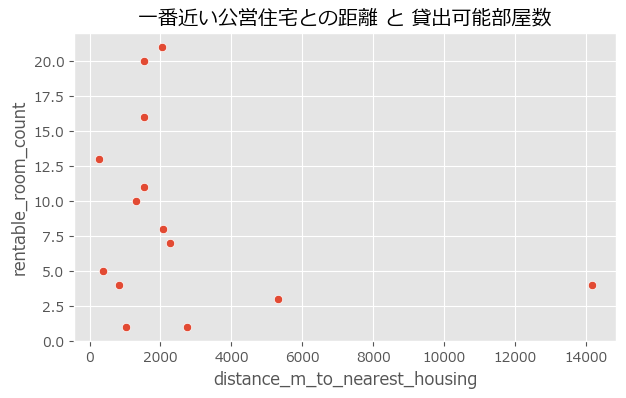

In [18]:
plt.figure(figsize=(7, 4))
sns.scatterplot(
    data=df,
    x="distance_m_to_nearest_housing",
    y="rentable_room_count"
)
plt.title('一番近い公営住宅との距離 と 貸出可能部屋数')
plt.savefig('../output/public_facilities_scale/public_facilities_size_vs_housing_distance.png', bbox_inches='tight')
plt.show()

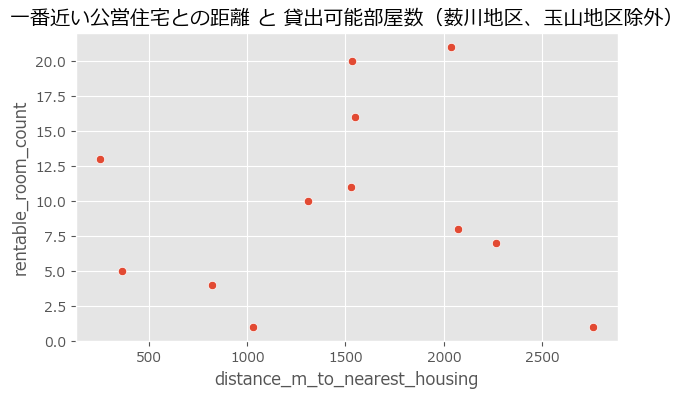

In [19]:
## 薮川地区は10km以上、玉山地区も5km以上距離があるため、除外して再比較
df_distance_under_5000 = sorted_df.query('distance_m_to_nearest_housing < 5000')
plt.figure(figsize=(7, 4))
sns.scatterplot(
    data=df_distance_under_5000,
    x="distance_m_to_nearest_housing",
    y="rentable_room_count"
)
plt.title('一番近い公営住宅との距離 と 貸出可能部屋数（薮川地区、玉山地区除外）')
plt.savefig('../output/public_facilities_scale/public_hall_size_vs_housing_distance_without_outliers.png', bbox_inches='tight')
plt.show()

### 所感
- 意外と相関はなさそう

## 【集計】

In [20]:
# 人口データと結合できなかった公民館を除外
dropna_df = df.dropna(subset=['total_population'])
dropna_df.shape

(10, 51)

In [21]:
# 男性の人口カラム抽出
male_cols = [col for col in df.columns 
             if "male" in col
             and "population" not in col
             and "female" not in col
            ]
# 女性の人口カラム抽出
female_cols = [col for col in df.columns 
               if "female" in col
               and "population" not in col
              ]

In [22]:
# 年齢ごとの人口データを男女別、総人口算出
dropna_df["男性人口"] = dropna_df[male_cols].sum(axis=1)
dropna_df["女性人口"] = dropna_df[female_cols].sum(axis=1)
dropna_df["総人口"] = dropna_df["男性人口"] + dropna_df["女性人口"]

In [23]:
# 集計結果と元々集計されたカラムが一致しているかチェック
print("総人口 ：",(dropna_df["total_population"] == dropna_df["総人口"]).all())
print("男性人口 ：",(dropna_df["male_population"] == dropna_df["男性人口"]).all())
print("女性人口 ：",(dropna_df["female_population"] == dropna_df["女性人口"]).all())

総人口 ： True
男性人口 ： True
女性人口 ： True


In [24]:
# 年齢3区分別（15歳未満人口、15～64歳人口、65歳以上人口）※総務省統計局より
# カラムリスト
male_under_15_cols = ["male_0_4","male_5_9","male_10_14"]
male_15_64_cols = ["male_15_19","male_20_24","male_25_29",'male_30_34',
                   'male_35_39','male_40_44','male_45_49','male_50_54','male_55_59','male_60_64']
male_65_plus_cols =['male_65_69','male_70_74','male_75_79','male_80_84','male_85_89','male_90_plus']
female_under_15_cols = ['female_0_4', 'female_5_9','female_10_14']
female_15_64_cols = ['female_15_19', 'female_20_24', 'female_25_29','female_30_34', 
                     'female_35_39', 'female_40_44', 'female_45_49','female_50_54', 'female_55_59', 'female_60_64']
female_65_plus_cols =['female_65_69', 'female_70_74', 'female_75_79', 'female_80_84', 'female_85_89','female_90_plus']

In [25]:
# 個数確認
print("15歳未満男性カラム数  :",len(male_under_15_cols))
print("15歳-64歳男性カラム数 :",len(male_15_64_cols))
print("65歳以上男性カラム数 :",len(male_65_plus_cols))
print("合計 :",len(male_65_plus_cols)+len(male_15_64_cols)+len(male_65_plus_cols))
print("15歳未満女性カラム数  :",len(female_under_15_cols))
print("15歳-64歳女性カラム数 :",len(female_15_64_cols))
print("65歳以上女性カラム数 :",len(female_65_plus_cols))
print("合計 :",len(female_65_plus_cols)+len(female_15_64_cols)+len(female_65_plus_cols))

15歳未満男性カラム数  : 3
15歳-64歳男性カラム数 : 10
65歳以上男性カラム数 : 6
合計 : 22
15歳未満女性カラム数  : 3
15歳-64歳女性カラム数 : 10
65歳以上女性カラム数 : 6
合計 : 22


In [26]:
# 年齢3区分別人口集計
dropna_df["male_under_15"] = dropna_df[male_under_15_cols].sum(axis=1)
dropna_df["male_15_64"] = dropna_df[male_15_64_cols].sum(axis=1)
dropna_df["male_65_plus"] = dropna_df[male_65_plus_cols].sum(axis=1)
dropna_df["female_under_15"] = dropna_df[female_under_15_cols].sum(axis=1)
dropna_df["female_15_64"] = dropna_df[female_15_64_cols].sum(axis=1)
dropna_df["female_65_plus"] = dropna_df[female_65_plus_cols].sum(axis=1)
dropna_df["population_under_15"] = dropna_df["male_under_15"] + dropna_df["female_under_15"]
dropna_df["population_15_64"] = dropna_df["male_15_64"] + dropna_df["female_15_64"]
dropna_df["population_65_plus"] = dropna_df["male_65_plus"] + dropna_df["female_65_plus"]

In [27]:
# 人口比率(％) (percent)
dropna_df["male_under_15_percent"] = dropna_df["male_under_15"] / dropna_df["male_population"] * 100
dropna_df["male_15_64_percent"] = dropna_df["male_15_64"] / dropna_df["male_population"] * 100
dropna_df["male_65_plus_percent"] = dropna_df["male_65_plus"] / dropna_df["male_population"] * 100
dropna_df["female_under_15_percent"] = dropna_df["female_under_15"] / dropna_df["female_population"] * 100
dropna_df["female_15_64_percent"] = dropna_df["female_15_64"] / dropna_df["female_population"] * 100
dropna_df["female_65_plus_percent"] = dropna_df["female_65_plus"] / dropna_df["female_population"] * 100
dropna_df["population_under_15_percent"] = dropna_df["population_under_15"] / dropna_df["total_population"] * 100
dropna_df["population_15_64_percent"] = dropna_df["population_15_64"] / dropna_df["total_population"] * 100
dropna_df["population_65_plus_percent"] = dropna_df["population_65_plus"] / dropna_df["total_population"] * 100
dropna_df["population_male_percent"] = dropna_df["male_population"] / dropna_df["total_population"]  * 100
dropna_df["population_female_percent"] = dropna_df["female_population"] / dropna_df["total_population"]  * 100

In [28]:
## 算出した比率を合計して100になるかチェック
# 浮動小数点誤差により == 100 は不安定なため isclose を使用
# 小数誤差を許容して「ほぼ」100か判定
print("男性人口割合 ：", np.isclose(dropna_df["male_under_15_percent"]+dropna_df["male_15_64_percent"]+dropna_df["male_65_plus_percent"], 100))
print("女性人口割合 ：",np.isclose(dropna_df["female_under_15_percent"]+dropna_df["female_15_64_percent"]+dropna_df["female_65_plus_percent"], 100))
print("総人口割合　 ：",np.isclose(dropna_df["population_under_15_percent"]+dropna_df["population_15_64_percent"]+dropna_df["population_65_plus_percent"], 100))
print("総人口男女比 ：",np.isclose(dropna_df["population_male_percent"]+dropna_df["population_female_percent"], 100))

男性人口割合 ： [ True  True  True  True  True  True  True  True  True  True]
女性人口割合 ： [ True  True  True  True  True  True  True  True  True  True]
総人口割合　 ： [ True  True  True  True  True  True  True  True  True  True]
総人口男女比 ： [ True  True  True  True  True  True  True  True  True  True]


In [29]:
# 市営住宅との距離が遠い順に並び替え
sorted_dropna_df = dropna_df.sort_values("distance_m_to_nearest_housing", ascending=False)
sorted_dropna_df[["facility_name", "distance_m_to_nearest_housing",
                  "population_under_15", 'population_15_64', "population_65_plus","total_population"]]

,facility_name,distance_m_to_nearest_housing,population_under_15,population_15_64,population_65_plus,total_population
4,盛岡市飯岡地区公民館,2758.713220,101.0,541.0,391.0,1033.0
6,盛岡市見前地区公民館,2265.134495,278.0,1737.0,456.0,2471.0
12,盛岡市松園地区公民館,2069.572058,216.0,1202.0,1214.0,2632.0
1,盛岡市中央公民館,2036.267547,93.0,592.0,272.0,957.0
3,盛岡市河南公民館,1546.762097,42.0,284.0,211.0,537.0
5,盛岡市都南公民館,1535.108902,1015.0,4922.0,2295.0,8232.0
0,盛岡市上田公民館,1525.622140,376.0,2846.0,1039.0,4261.0
8,盛岡市乙部地区公民館,1028.067441,158.0,1101.0,792.0,2051.0
7,盛岡市見前南地区公民館,366.193386,653.0,2976.0,1428.0,5057.0
13,盛岡市西部公民館,254.341376,162.0,910.0,524.0,1596.0


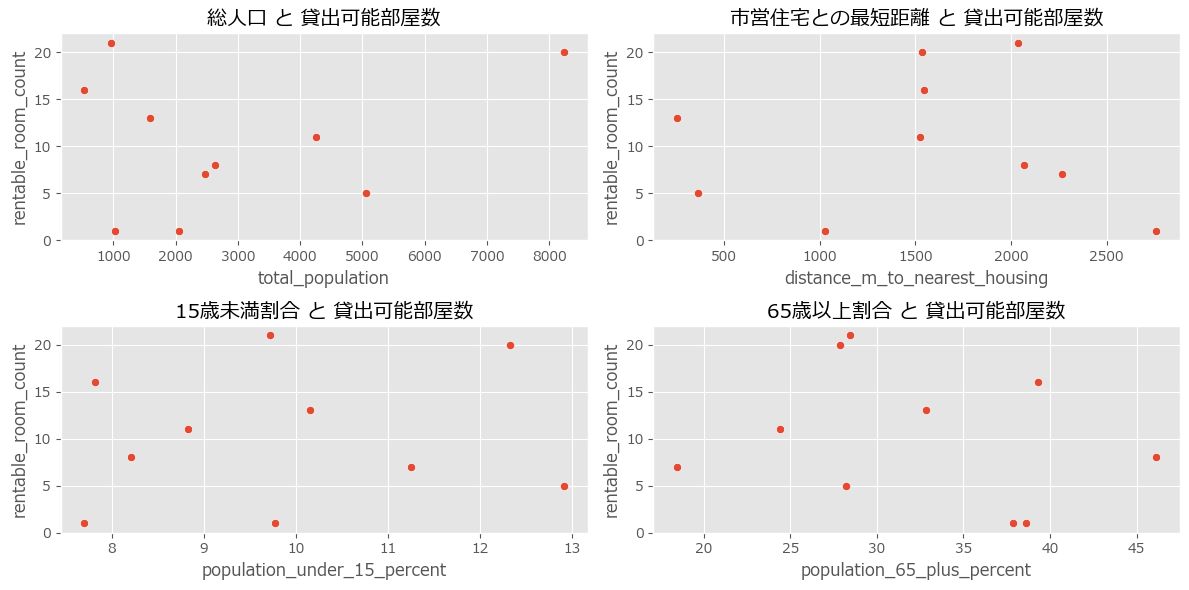

In [31]:
## 薮川地区は10km以上、玉山地区も5km以上距離があるため、除外して再比較
#df_distance_under_5000 = sorted_df.query('distance_m_to_nearest_housing < 5000')
fig, axes = plt.subplots(2, 2, figsize=(12, 6))
#plt.figure(figsize=(7, 4))
sns.scatterplot(
    ax=axes[0][0],
    data=dropna_df,
    x="total_population",
    y="rentable_room_count"
)
sns.scatterplot(
    ax=axes[0][1],
    data=dropna_df,
    x="distance_m_to_nearest_housing",
    y="rentable_room_count"
)
sns.scatterplot(
    ax=axes[1][0],
    data=dropna_df,
    x="population_under_15_percent",
    y="rentable_room_count"
)
sns.scatterplot(
    ax=axes[1][1],
    data=dropna_df,
    x="population_65_plus_percent",
    y="rentable_room_count"
)
axes[0][0].set_title("総人口 と 貸出可能部屋数")
axes[0][1].set_title("市営住宅との最短距離 と 貸出可能部屋数")
axes[1][0].set_title("15歳未満割合 と 貸出可能部屋数")
axes[1][1].set_title("65歳以上割合 と 貸出可能部屋数")

plt.tight_layout()
# regional_characteristics - 地域特性
plt.savefig('../output/public_facilities_scale/public_hall_size_vs_regional_characteristics.png', bbox_inches='tight')
plt.show()

In [32]:
# 相関行列を作成してみる
dropna_df[
    ["rentable_room_count", "distance_m_to_nearest_housing", "total_population", "population_under_15_percent", "population_65_plus_percent"]
].corr()

,rentable_room_count,distance_m_to_nearest_housing,total_population,population_under_15_percent,population_65_plus_percent
rentable_room_count,1.000000,-0.041107,0.200532,0.124434,-0.230521
distance_m_to_nearest_housing,-0.041107,1.000000,-0.243426,-0.219143,0.052607
total_population,0.200532,-0.243426,1.000000,0.639023,-0.375943
population_under_15_percent,0.124434,-0.219143,0.639023,1.000000,-0.623171
population_65_plus_percent,-0.230521,0.052607,-0.375943,-0.623171,1.000000


#### 所感
- 「貸出可能部屋数が多い」=「地域の規模も大きい」等の関係性を予測したけど意外と「市営住宅との距離」「人口割合」「総人口」の要素とは相関関係がないっぽい
- 　→　公民館の規模は現在扱っている情報では説明できないところが多い
- 　→　では何と関係しているのか
- 